# Import Library & Set Globals

In [31]:
# base
import os
import sys
import warnings
import logging
import pickle

# data manipulation
import pickle
import pandas as pd
import itables
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from rpy2.robjects.conversion import localconverter
from rpy2.rinterface_lib.callbacks import logger as rpy2_logger

# single cell
import scanpy as sc

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

# R_preload()
%load_ext rpy2.ipython

study = "Wang2025"

CORES = 10
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]

%matplotlib inline
mpl.rcdefaults()
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.ERROR)
rpy2_logger.setLevel(logging.ERROR)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
itables.init_notebook_mode(connected=True)
converter = get_converter()

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


# Access & Preprocess adata

In [2]:
study_name = "Wang2025_download"

experiment_dir = Path("counts", study_name)
filename = ""
filetype = ".mtx"
data_dir = DATADIR
convertR = False

adatas = GetSingleCellData(DATADIR, experiment_dir, filename, filetype, convertR)


for adata in adatas:
    col = adata.obs["Identifier"].str.split("_", expand=True)[1]
    adata.obs["Age"] = col.str[:-1]
    adata.obs["Sample"] = col.str[-1]
    adata = Filter_QC(adata)
    adata = Filter_GeneGroup(adata, perc_threshold=10)

Cells removed by gene/count filters: 686 (10.54%)
Cells removed by gene/count filters: 252 (8.43%)
Cells removed by gene/count filters: 298 (10.60%)
Cells removed by gene/count filters: 299 (11.36%)
Cells removed by gene/count filters: 1120 (17.20%)
Cells removed by gene/count filters: 213 (8.08%)
Cells removed by gene/count filters: 69 (4.90%)
Cells removed by gene/count filters: 422 (7.66%)
Cells removed by gene/count filters: 327 (12.55%)
Cells removed by gene/count filters: 273 (3.26%)
Cells removed by gene/count filters: 437 (6.03%)
Cells removed by gene/count filters: 519 (5.83%)


In [3]:
for method in DOUBLETMETHODS:
    adatas = [Filter_Doublet(adata, method, remove=False) for adata in tqdm(adatas)]

  0%|          | 0/12 [00:00<?, ?it/s]


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

  8%|▊         | 1/12 [01:33<17:11, 93.81s/it]

0       singlet
1       singlet
2       doublet
3       singlet
4       singlet
         ...   
5818    singlet
5819    singlet
5820    singlet
5821    singlet
5822    singlet
Length: 5823, dtype: object


 17%|█▋        | 2/12 [01:54<08:27, 50.77s/it]

...

 83%|████████▎ | 10/12 [07:28<02:04, 62.04s/it]

  0%|          | 0/10 [00:00<?, ?it/s]

 92%|█████████▏| 11/12 [08:43<01:06, 66.07s/it]

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 12/12 [04:39<00:00, 23.26s/it]


Cells removed by gene/count filters: 23 (0.04%)
Saving normalized counts in layer 'normalized'.
Finding HVGs...
Staring PCA with gene mask highly_variable at 50 comps, saved at .obsm[PCA_hvg]


2026-01-20 11:54:33,989 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-01-20 11:54:33 | [INFO] Running Harmony (PyTorch on cpu)
2026-01-20 11:54:33,991 - harmonypy - INFO -   Parameters:
2026-01-20 11:54:33 | [INFO]   Parameters:
2026-01-20 11:54:33,993 - harmonypy - INFO -     max_iter_harmony: 10
2026-01-20 11:54:33 | [INFO]     max_iter_harmony: 10
2026-01-20 11:54:33,994 - harmonypy - INFO -     max_iter_kmeans: 20
2026-01-20 11:54:33 | [INFO]     max_iter_kmeans: 20
2026-01-20 11:54:33,996 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-01-20 11:54:33 | [INFO]     epsilon_cluster: 1e-05
2026-01-20 11:54:33,997 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-01-20 11:54:33 | [INFO]     epsilon_harmony: 0.0001
2026-01-20 11:54:33,998 - harmonypy - INFO -     nclust: 100
2026-01-20 11:54:33 | [INFO]     nclust: 100
2026-01-20 11:54:34,000 - harmonypy - INFO -     block_size: 0.05
2026-01-20 11:54:34 | [INFO]     block_size: 0.05
2026-01-20 11:54:34,002 - harmon

Integrating by Column Identifier: ['GSM5707532_Young2' 'GSM5707537_YoungCD1' 'GSM5707536_AgeCD3'
 'GSM5707538_YoungCD2' 'GSM5707531_Young1' 'GSM5707539_YoungCD3'
 'GSM5707535_AgeCD2' 'GSM5707533_Young3' 'GSM5707534_AgeCD1'
 'GSM5707528_Age1' 'GSM5707530_Age3' 'GSM5707529_Age2']


2026-01-20 11:54:35,533 - harmonypy - INFO - KMeans initialization complete.
2026-01-20 11:54:35 | [INFO] KMeans initialization complete.
2026-01-20 11:54:35,593 - harmonypy - INFO - Iteration 1 of 10
2026-01-20 11:54:35 | [INFO] Iteration 1 of 10
2026-01-20 11:54:37,387 - harmonypy - INFO - Iteration 2 of 10
2026-01-20 11:54:37 | [INFO] Iteration 2 of 10
2026-01-20 11:54:39,056 - harmonypy - INFO - Iteration 3 of 10
2026-01-20 11:54:39 | [INFO] Iteration 3 of 10
2026-01-20 11:54:41,117 - harmonypy - INFO - Iteration 4 of 10
2026-01-20 11:54:41 | [INFO] Iteration 4 of 10
2026-01-20 11:54:42,923 - harmonypy - INFO - Iteration 5 of 10
2026-01-20 11:54:42 | [INFO] Iteration 5 of 10
2026-01-20 11:54:44,716 - harmonypy - INFO - Iteration 6 of 10
2026-01-20 11:54:44 | [INFO] Iteration 6 of 10
2026-01-20 11:54:46,501 - harmonypy - INFO - Iteration 7 of 10
2026-01-20 11:54:46 | [INFO] Iteration 7 of 10
2026-01-20 11:54:58,173 - harmonypy - INFO - Iteration 8 of 10
2026-01-20 11:54:58 | [INFO] 

Starting UMAP...


... storing 'Identifier' as categorical
... storing 'Age' as categorical
... storing 'Sample' as categorical


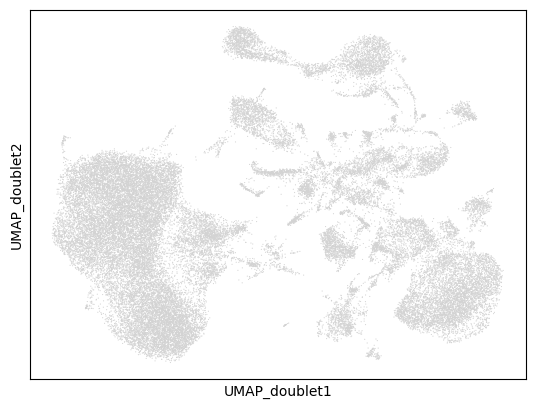

Starting LocalMAP...


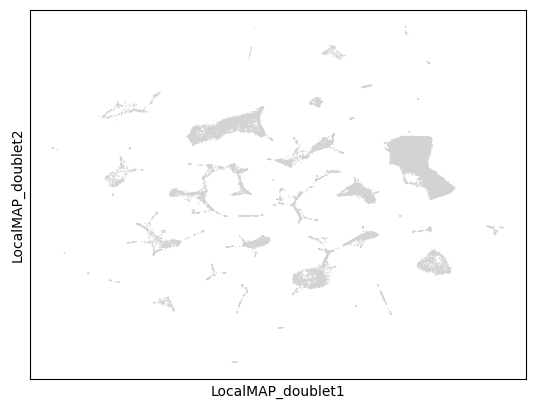

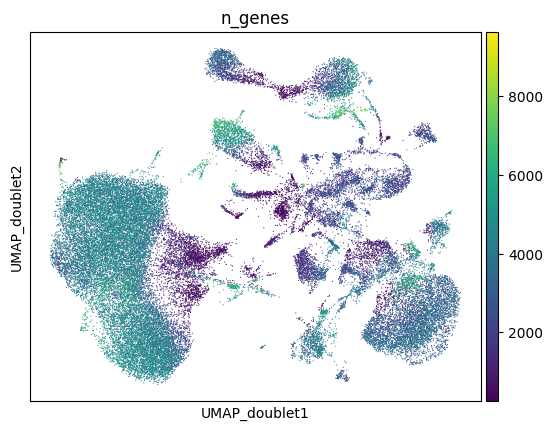

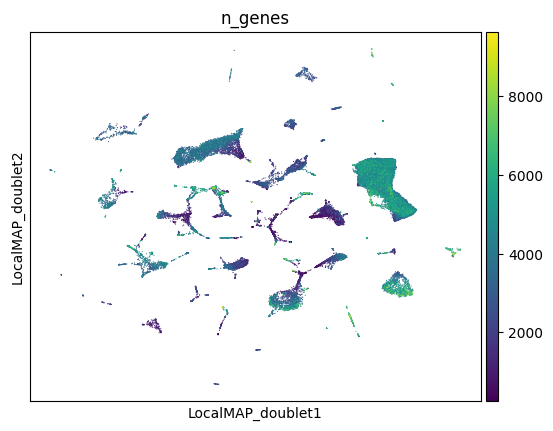

100%|██████████| 3/3 [01:47<00:00, 35.94s/it]


AnnData object with n_obs × n_vars = 45227 × 17987
    obs: 'Identifier', 'Age', 'Sample', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'predicted_doublet-scDblFinder', 'doublet_score-scDblFinder', 'predicted_doublet-DoubletFinder', 'doublet_score-DoubletFinder', 'predicted_doublet-doubletdetection', 'doublet_score-doubletdetection', 'predicted_doublet-scrublet', 'doublet_score-scrublet', 'leiden_doublets_0.5', 'leiden_doublets_0.7', 'leiden_doublets_1.0'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mito', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'methods', 'log1p', 'hvg', 'PCA_hvg', 'neighbors_doublet', 'UMAP_doublet', 'leiden_doublets_0.5', 'leiden_double

In [4]:
adata = sc.concat(adatas, join="outer")
adata = Filter_QC(adata)
adata = Filter_GeneGroup(adata, perc_threshold=10)

batch_column = "Identifier"
hvg_kind = "seurat_v3"
int_kind = "harmony"
pca_key = "PCA_hvg"
neighbors_key = "neighbors_doublet"
key = "leiden_doublets"

Normalize(adata, kind="log1p", batch_column=batch_column)
FindVariableGenes(adata, kind=hvg_kind, batch_column=batch_column)
PCA(adata, key=pca_key)
Integrate(adata, pca_key=pca_key, kind=int_kind, batch_column=batch_column)
Visualize(adata, key="doublet")

sc.pl.embedding(adata, basis="UMAP_doublet", color="n_genes")
sc.pl.embedding(adata, basis="LocalMAP_doublet", color="n_genes")

Cluster(adata, key, [0.5, 0.7, 1.0], neighbor_key=neighbors_key)

adata.write(DATADIR / "processed" / "single_cell" / study / "has_doublets.h5ad")
adata

# Load and Clean

In [22]:
adata = sc.read_h5ad(
    DATADIR / "processed" / "single_cell" / study / "has_doublets.h5ad"
)

predicted_doublet-scDblFinder         3680
predicted_doublet-DoubletFinder       3438
predicted_doublet-doubletdetection    3006
predicted_doublet-scrublet             185
dtype: int64


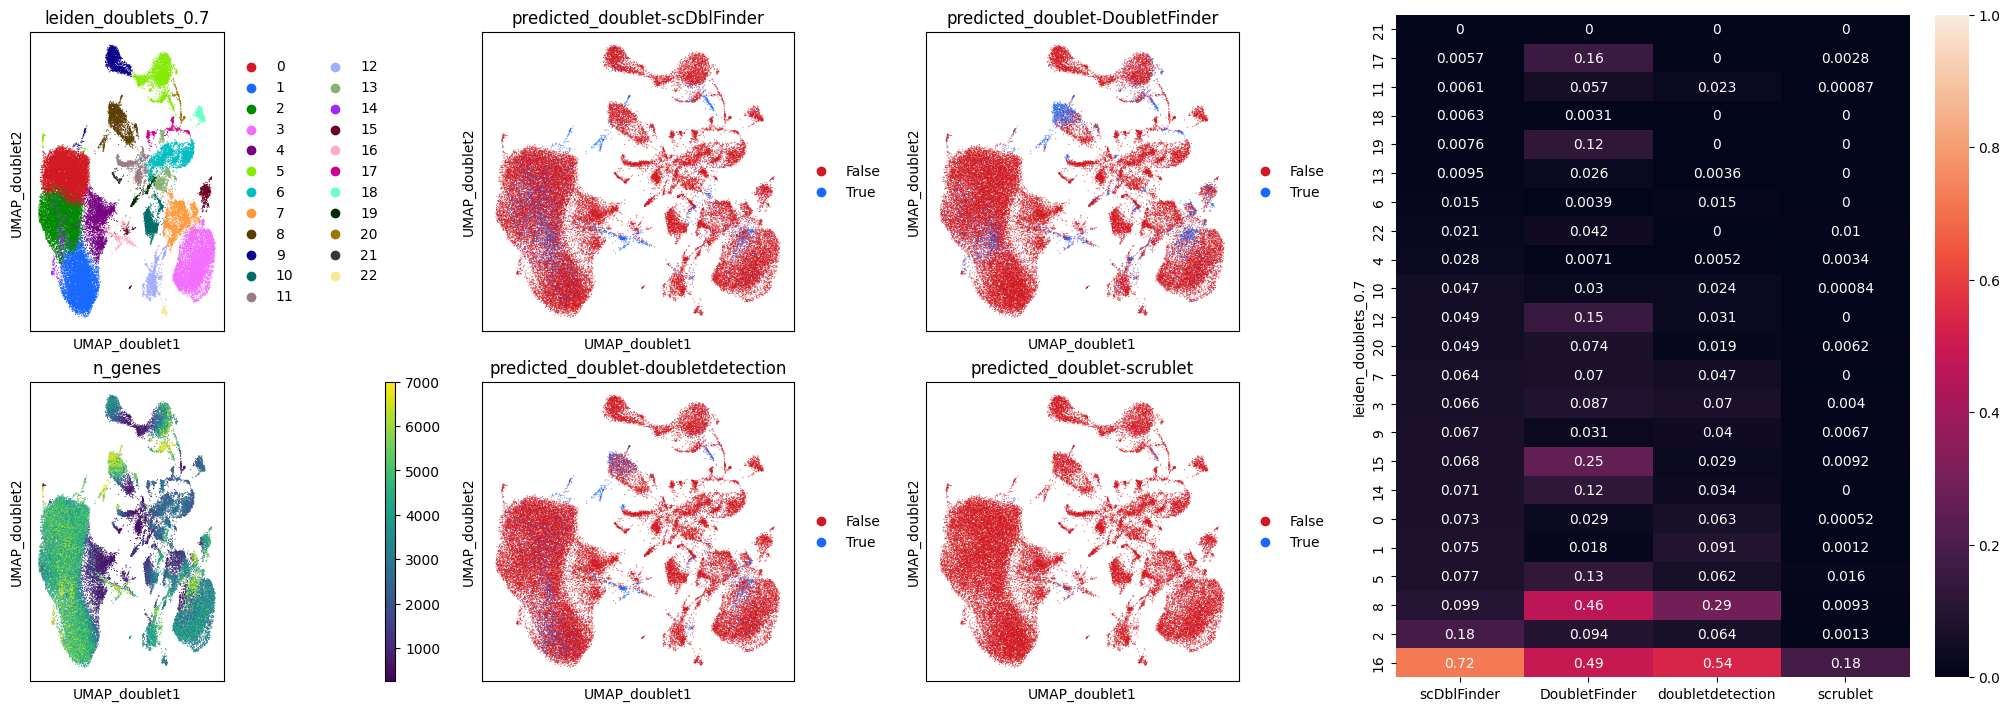

In [24]:
key = "leiden_doublets"
resolution = 0.7
cluster_key = f"{key}_{resolution:.1f}"
embedding = "UMAP_doublet"

check_doublets(adata, embedding, cluster_key)
print(adata.obs[[f"predicted_doublet-{m}" for m in DOUBLETMETHODS]].sum(axis=0))

2139


Text(0.02, 0.02, 'n = 45227')

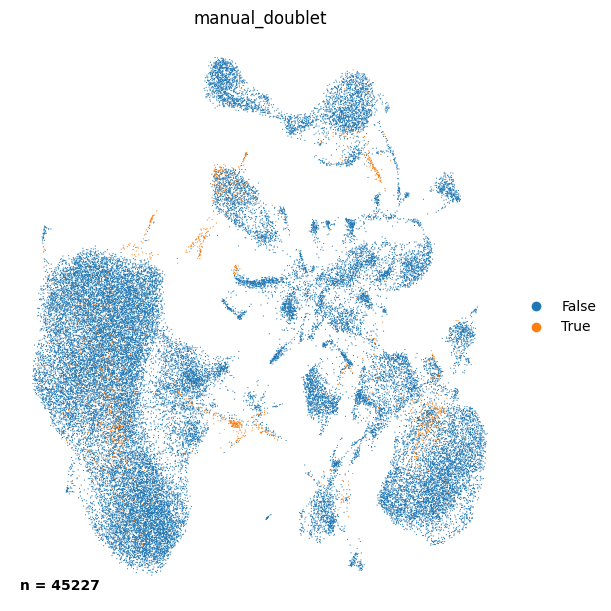

In [29]:
multi_doublet = adata.obs[[f"predicted_doublet-{m}" for m in DOUBLETMETHODS]].sum(
    axis=1
)

# doublet_clusters = pd.Series([11, 15, 16, 23, 21, 26, 14, 28]).astype(str)
adata.obs["manual_doublet"] = multi_doublet >= 2
print(adata.obs["manual_doublet"].sum())

f, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))
sc.pl.embedding(
    adata, basis=embedding, color="manual_doublet", frameon=False, ax=ax, show=False
)
ax.annotate(
    f"n = {adata.shape[0]}",
    (0.02, 0.02),
    fontweight="bold",
    fontsize=10,
    xycoords="axes fraction",
)

In [30]:
# save
annotation = "doublet_cleaned"
adata[~adata.obs["manual_doublet"]].write(
    DATADIR / "processed" / "single_cell" / study / f"{annotation}.h5ad"
)

In [32]:
adata = sc.read_h5ad(
    DATADIR / "processed" / "single_cell" / study / f"{annotation}.h5ad"
)